# Waze User Churn Prediction - Exploratory Data Analysis & Machine Learning

## Project Overview

This project focuses on analyzing Waze user data to understand factors associated with user churn and develop a machine learning model to predict users who are likely to stop using the Waze navigation app.

This notebook represents the exploratory data analysis (EDA) phase of the project, where the dataset is inspected, cleaned, and analyzed to identify patterns, trends, and relationships related to user churn. The insights gained from this phase will support feature engineering and machine learning model development in later stages.

The analysis includes:
- Data inspection and understanding
- Data cleaning and preparation
- Missing value analysis
- Outlier detection and handling
- Exploratory data analysis (EDA)
- Data visualization
- Feature exploration and insight generation

## Business Objective

The objective is to support Waze's data team by identifying behavioral patterns associated with user churn and preparing the data for developing a machine learning model that can help improve user retention strategies.

## Project Workflow

This project follows a complete data science workflow:

1. **Exploratory Data Analysis (EDA)**
   - Understand the dataset structure
   - Clean and prepare data
   - Analyze user behavior patterns
   - Identify factors related to churn

2. **Feature Engineering**
   - Transform and select relevant features
   - Prepare data for modeling

3. **Machine Learning Modeling**
   - Build classification models to predict user churn
   - Evaluate model performance
   - Identify important predictors of churn

4. **Insights & Recommendations**
   - Communicate findings
   - Provide recommendations to support user retention

## PACE Framework

This project follows the PACE framework:

- **Plan:** Define the business problem, stakeholders, and analytical questions.
- **Analyze:** Explore, clean, and analyze the dataset to discover patterns.
- **Construct:** Build visualizations, engineer features, and develop machine learning models.
- **Execute:** Communicate insights, evaluate results, and provide recommendations.

# **Imports and data loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/waze_dataset.csv")

# **Analyze**

### - The data is already in a structured format, Each row represents a user

### - Only 700 rows have label missing Other variables have no missing values


### **Data exploration and cleaning**


In [4]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [6]:
df.shape

(14999, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [7]:
df.isna().sum()

,0
ID,0
label,700
sessions,0
drives,0
total_sessions,0
n_days_after_onboarding,0
total_navigations_fav1,0
total_navigations_fav2,0
driven_km_drives,0
duration_minutes_drives,0


In [8]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
# remove ID as it a redundant column
df.drop('ID', axis=1, inplace=True)

In [14]:
df.head()

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [15]:
unlabeled_users = df[df['label'].isnull()]

In [16]:
unlabeled_users.shape

(700, 12)

In [17]:
df = df.dropna(subset=['label'])

In [18]:
df.shape

(14299, 12)

In [20]:
df.isna().sum()

,0
label,0
sessions,0
drives,0
total_sessions,0
n_days_after_onboarding,0
total_navigations_fav1,0
total_navigations_fav2,0
driven_km_drives,0
duration_minutes_drives,0
activity_days,0


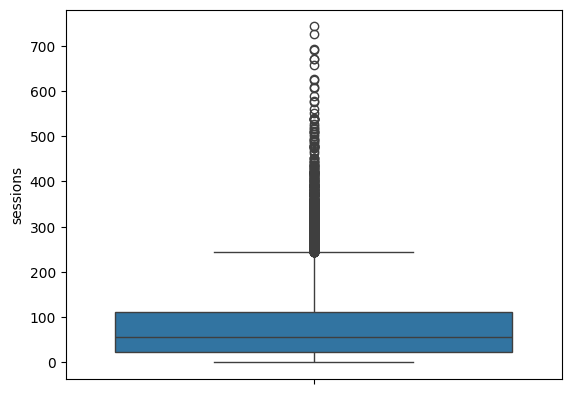

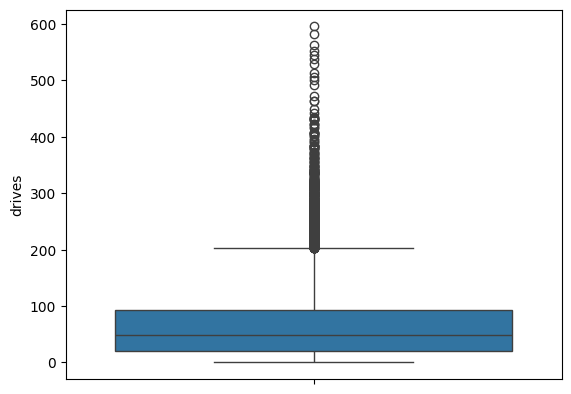

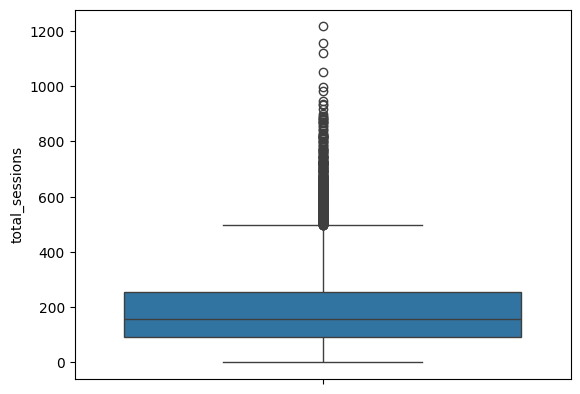

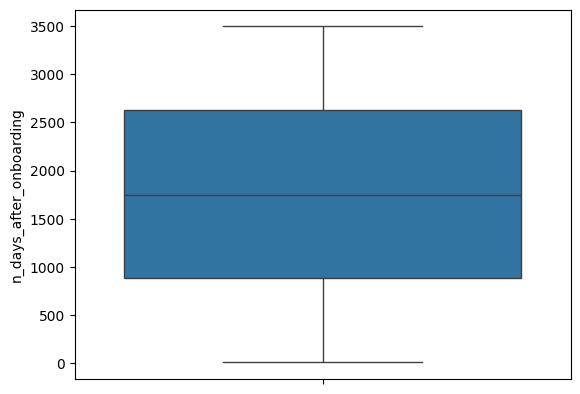

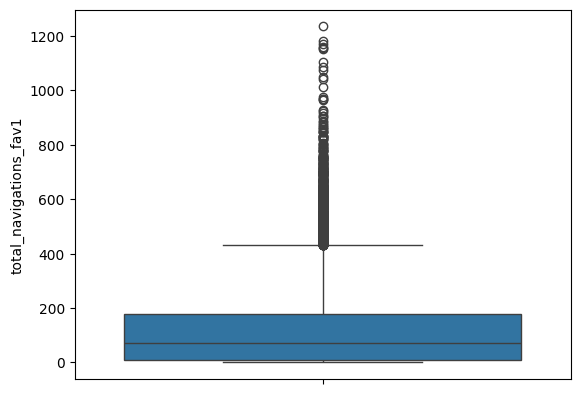

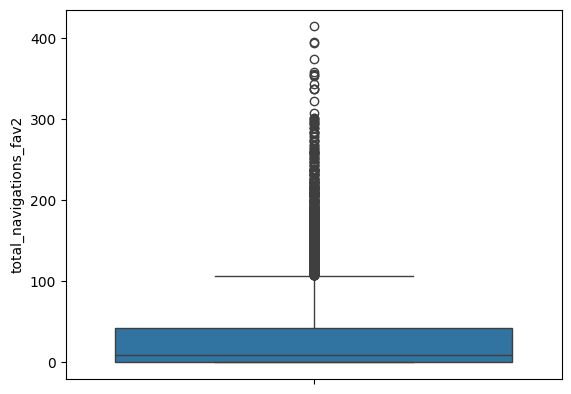

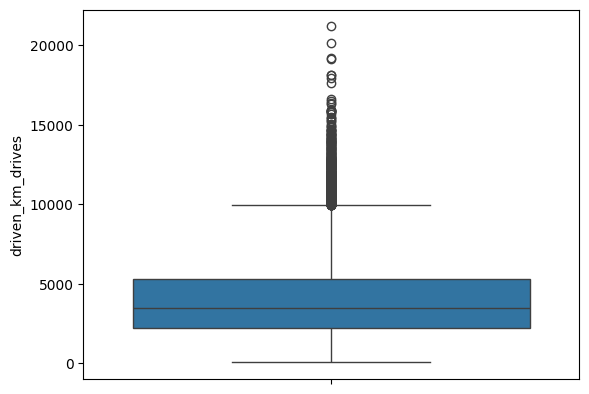

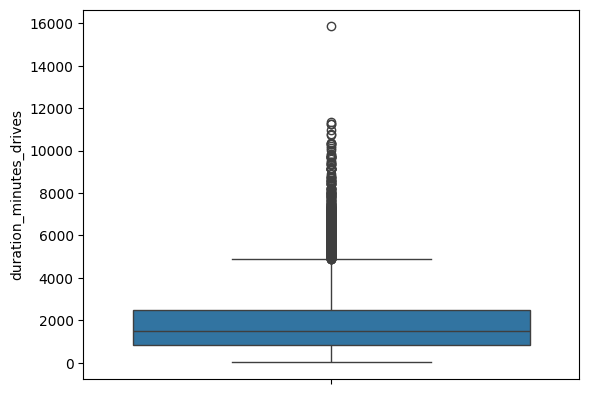

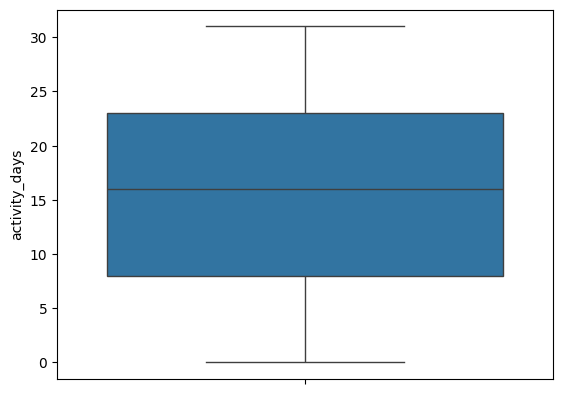

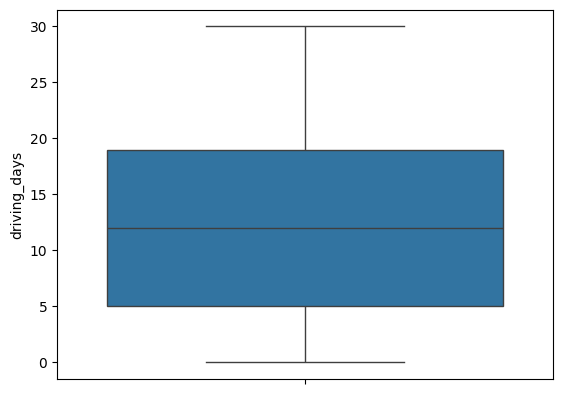

In [22]:
cols = [ "sessions" , "drives" , 'total_sessions' , "n_days_after_onboarding", 'total_navigations_fav1' , "total_navigations_fav2","driven_km_drives",
        "duration_minutes_drives", 'activity_days' , "driving_days"
]

for i in cols :
    sns.boxplot(df[i])
    plt.show()

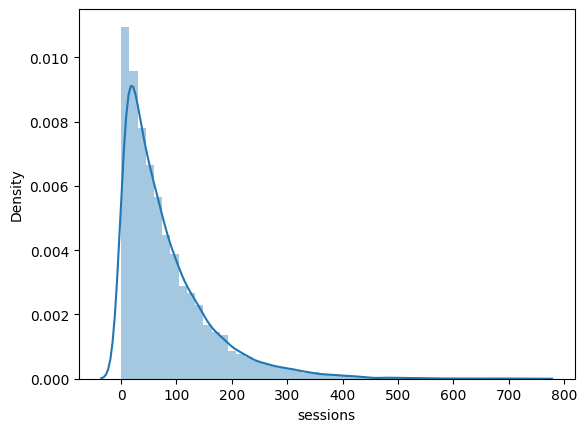

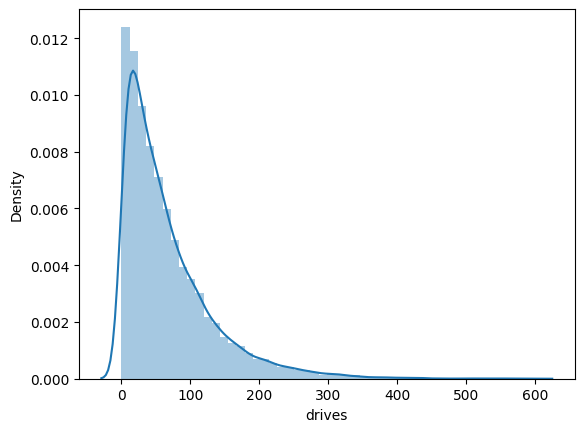

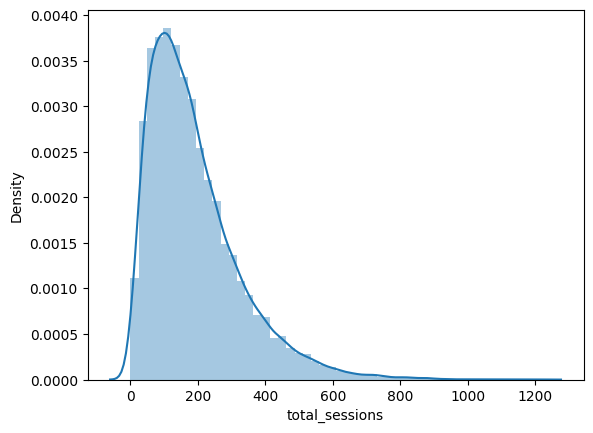

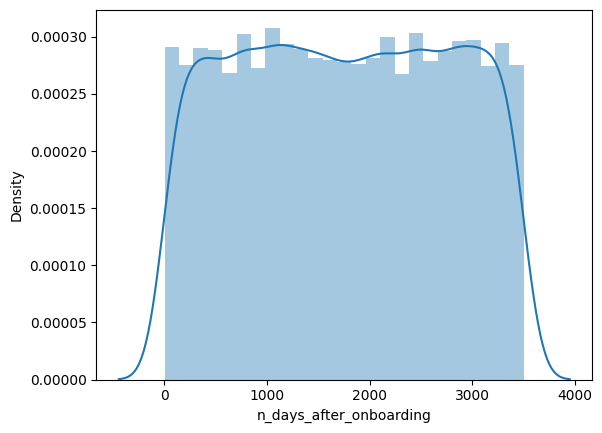

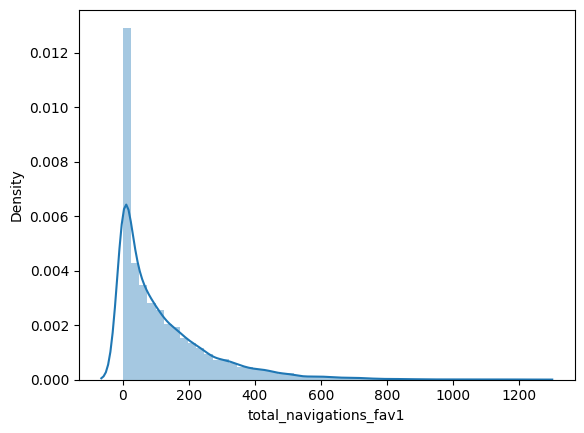

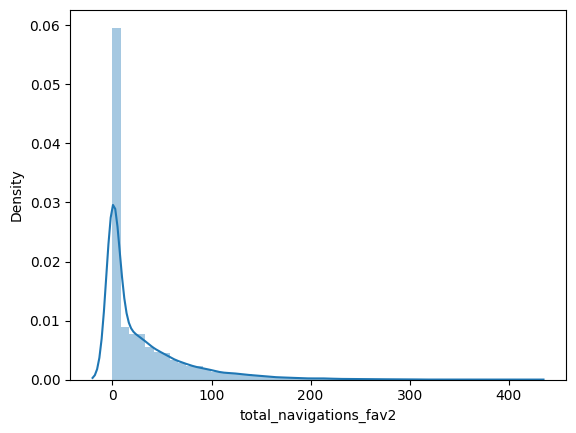

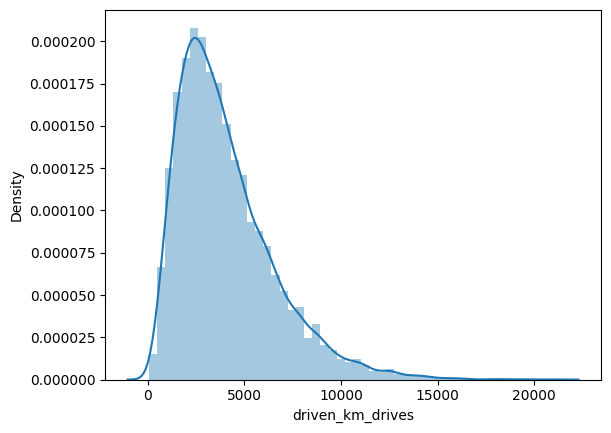

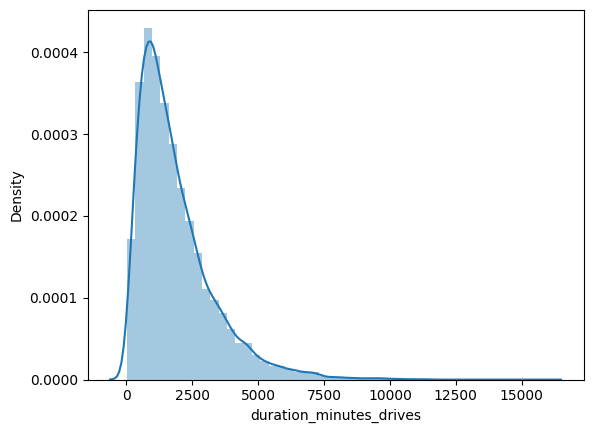

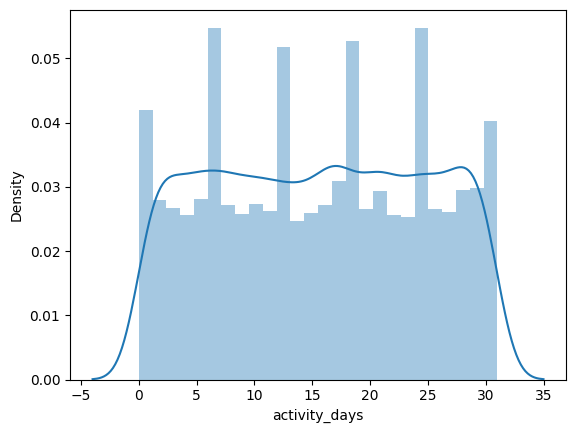

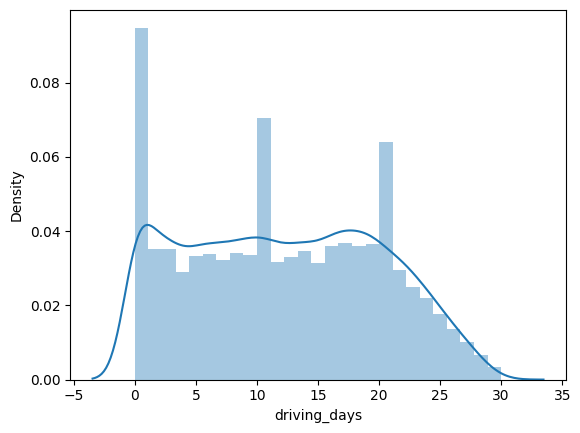

In [23]:
for i in cols :
    sns.distplot(df[i])
    plt.show()

In [26]:
cols2=["sessions" , "drives" , "total_sessions",'total_navigations_fav1' , "total_navigations_fav2","driven_km_drives",
        "duration_minutes_drives"]

In [27]:
for i in cols2 :

    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)

    IQR = Q3 - Q1

    upper_whisker = Q3 + (1.5*IQR)
    lower_whisker = Q1 - (1.5*IQR)

    lenght_upper = len(df[df[i] > upper_whisker])
    lenght_lower = len(df[df[i] < lower_whisker])

    print("Column Name" , i )
    print(f"lower_whisker :{lower_whisker}")
    print(f"upper_whisker :{upper_whisker}")
    print(f"length of data above upper : {lenght_upper}" )
    print(f"length of data below lower : {lenght_lower} \n" )

Column Name sessions
lower_whisker :-109.0
upper_whisker :243.0
length of data above upper : 709
length of data below lower : 0 

Column Name drives
lower_whisker :-89.5
upper_whisker :202.5
length of data above upper : 695
length of data below lower : 0 

Column Name total_sessions
lower_whisker :-154.16634299999998
upper_whisker :498.16452556
length of data above upper : 500
length of data below lower : 0 

Column Name total_navigations_fav1
lower_whisker :-242.0
upper_whisker :430.0
length of data above upper : 682
length of data below lower : 0 

Column Name total_navigations_fav2
lower_whisker :-64.5
upper_whisker :107.5
length of data above upper : 976
length of data below lower : 0 

Column Name driven_km_drives
lower_whisker :-2406.65846925
upper_whisker :9923.95054075
length of data above upper : 440
length of data below lower : 0 

Column Name duration_minutes_drives
lower_whisker :-1599.939955
upper_whisker :4907.0501746
length of data above upper : 613
length of data below 

In [29]:
def outlier_imputer(column_name, percentile):
    threshold = df[column_name].quantile(percentile)
    df.loc[df[column_name] > threshold, column_name] = threshold

    print('{:>25} | percentile: {} | threshold: {}'.format(column_name, percentile, threshold))

In [30]:
for column in ['sessions', 'drives', 'total_sessions',
               'driven_km_drives', 'duration_minutes_drives']:
               outlier_imputer(column, 0.95)

                 sessions | percentile: 0.95 | threshold: 243.0
                   drives | percentile: 0.95 | threshold: 200.0
           total_sessions | percentile: 0.95 | threshold: 455.4394923899998
         driven_km_drives | percentile: 0.95 | threshold: 8898.716274999999
  duration_minutes_drives | percentile: 0.95 | threshold: 4668.180091799999


In [31]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,76.539688,63.964683,183.717304,1751.822505,121.747395,29.638296,3944.558631,1792.911210,15.544653,12.182530
std,67.243178,55.127927,118.720520,1008.663834,147.713428,45.350890,2218.358258,1224.329759,9.016088,7.833835
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000
50%,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000
75%,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000
max,243.000000,200.000000,455.439492,3500.000000,1236.000000,415.000000,8898.716275,4668.180092,31.000000,30.000000


# **Feature Engineering**

In [32]:
# Measures the average number of sessions per active day (user engagement intensity)
df['sessions_per_activity_day'] = (df['sessions'] / (df['activity_days'] + 1))

In [33]:
# Measures the average number of drives per active day (driving frequency)
df['drives_per_activity_day'] = (df['drives'] / (df['activity_days'] + 1))

In [34]:
# Measures the proportion of onboarding days during which the user was active (activity consistency)
df['activity_consistency'] = (df['activity_days'] / (df['n_days_after_onboarding'] + 1))

In [35]:
# Calculates the average distance traveled per drive
df['avg_distance_per_drive'] = (df['driven_km_drives'] / (df['drives'] + 1))

In [36]:
# Calculates the average driving duration per drive
df['avg_duration_per_drive'] = (df['duration_minutes_drives'] / (df['drives'] + 1))

In [37]:
# Combines navigation counts to both favorite destinations into a single engagement feature
df['total_favorite_navigations'] = (df['total_navigations_fav1'] +df['total_navigations_fav2'])

In [38]:
# Measures how often app sessions result in an actual drive
df['drives_per_session_ratio'] = (df['drives'] / (df['sessions'] + 1))

In [41]:
# 1. Create `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

In [42]:
df.head()

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,sessions_per_activity_day,drives_per_activity_day,activity_consistency,avg_distance_per_drive,avg_duration_per_drive,total_favorite_navigations,drives_per_session_ratio,km_per_driving_day
0,retained,243,200,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,8.37931,6.896552,0.012297,13.078831,9.879478,208,0.819672,138.360267
1,retained,133,107,326.896596,1225,19,64,8898.716275,3160.472914,13,11,iPhone,9.50000,7.642857,0.010604,82.395521,29.263638,83,0.798507,808.974207
2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,7.60000,6.333333,0.005279,31.866134,16.778499,0,0.826087,382.393602
3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,6.12500,5.000000,0.437500,22.282710,14.321867,329,0.800000,304.530374
4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,3.00000,2.428571,0.017274,57.249304,17.674724,171,0.800000,219.455667


In [40]:
df.shape

(14299, 19)

# **Exploratory Data Analysis (EDA)**
### The objective of this analysis is to better understand user behavior and identify characteristics associated with user churn. Each visualization is designed to answer a specific business question that may provide insights for future machine learning modeling



# 1.  What is the overall churn rate?





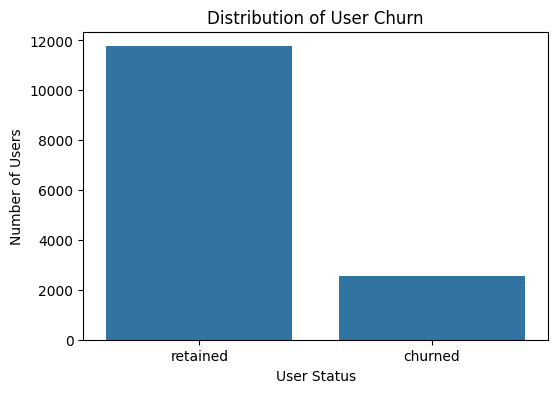

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')

plt.title("Distribution of User Churn")
plt.xlabel("User Status")
plt.ylabel("Number of Users")
plt.show()

In [46]:
df['label'].value_counts(normalize=True)*100

,proportion
label,
retained,82.264494
churned,17.735506


# 2.  How are user activity metrics distributed?

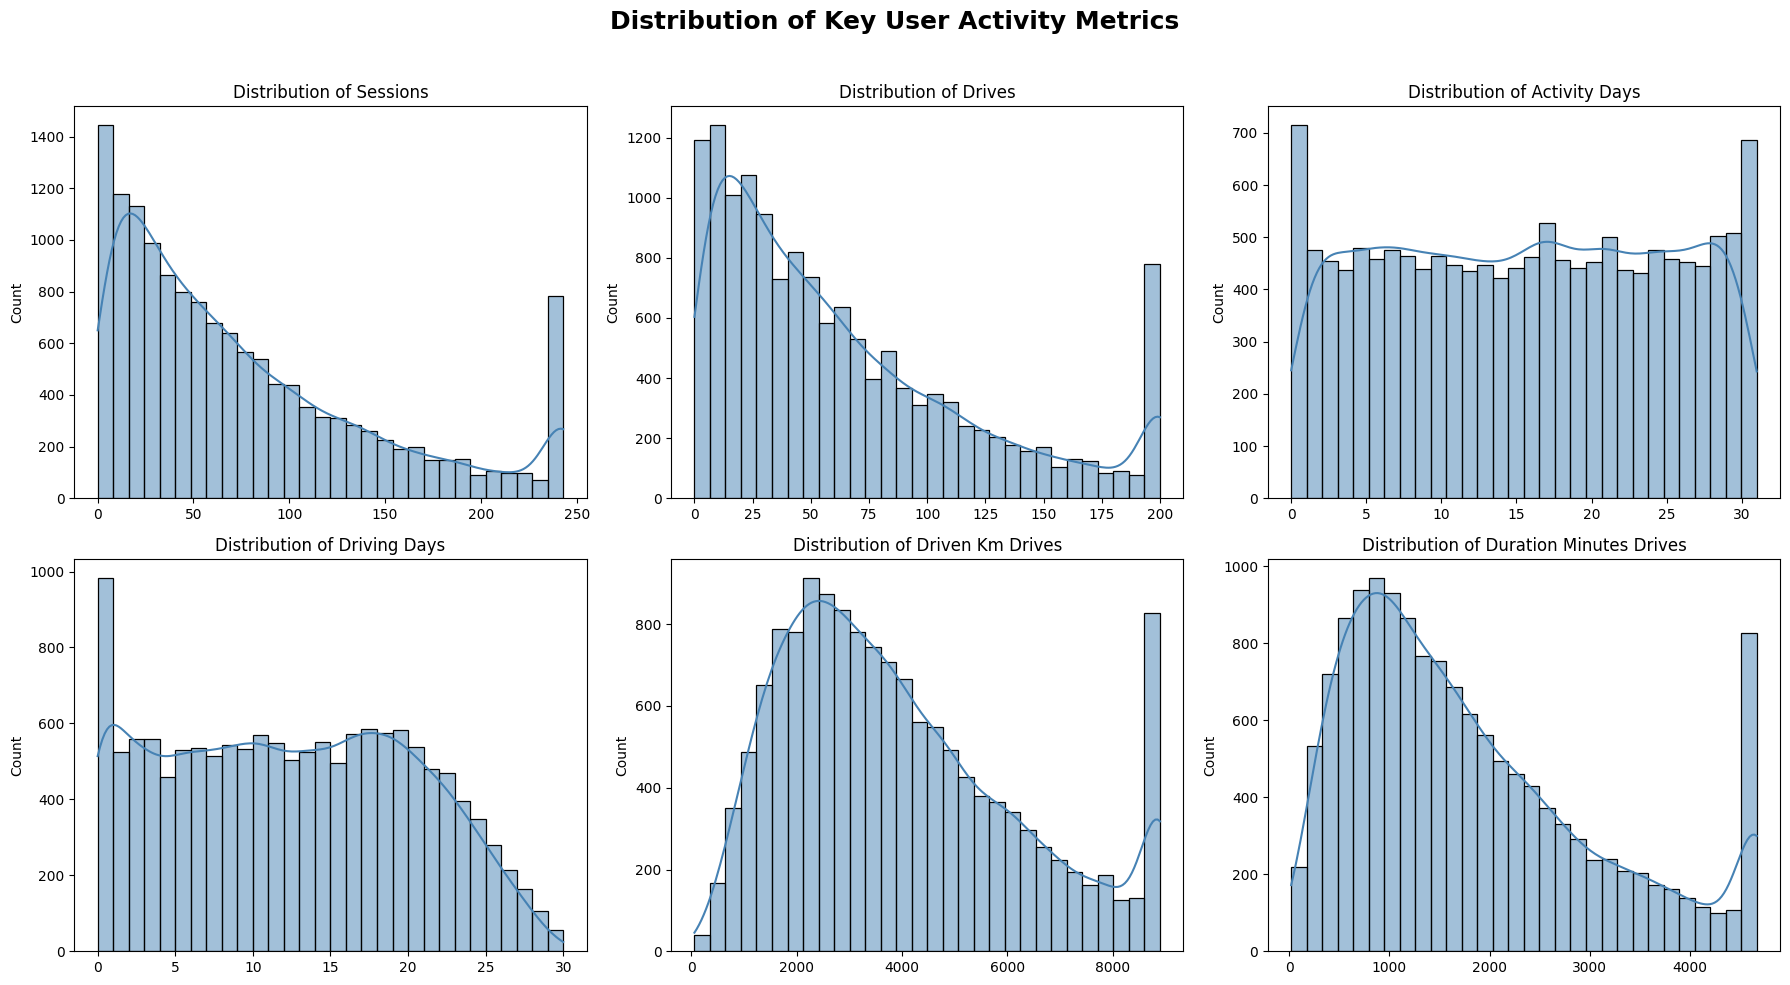

In [47]:
behavioral_cols = [
    'sessions',
    'drives',
    'activity_days',
    'driving_days',
    'driven_km_drives',
    'duration_minutes_drives'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, behavioral_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=ax,
        color='steelblue'
    )

    ax.set_title(f'Distribution of {col.replace("_", " ").title()}')
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Key User Activity Metrics', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 3. Does driving frequency differ between churned and retained users?


<Axes: xlabel='label', ylabel='drives'>

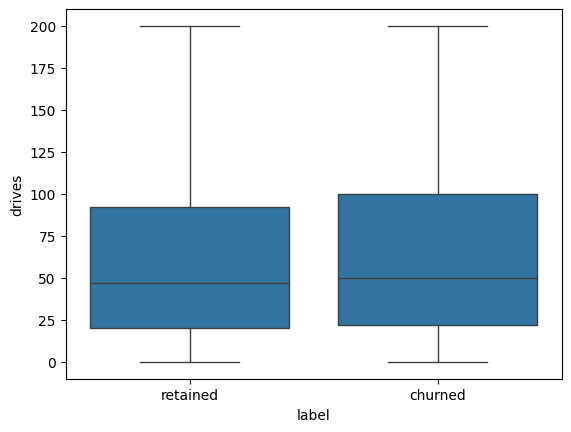

In [50]:
sns.boxplot(data=df,x='label',y='drives')

# 4. Are newer users more likely to churn?

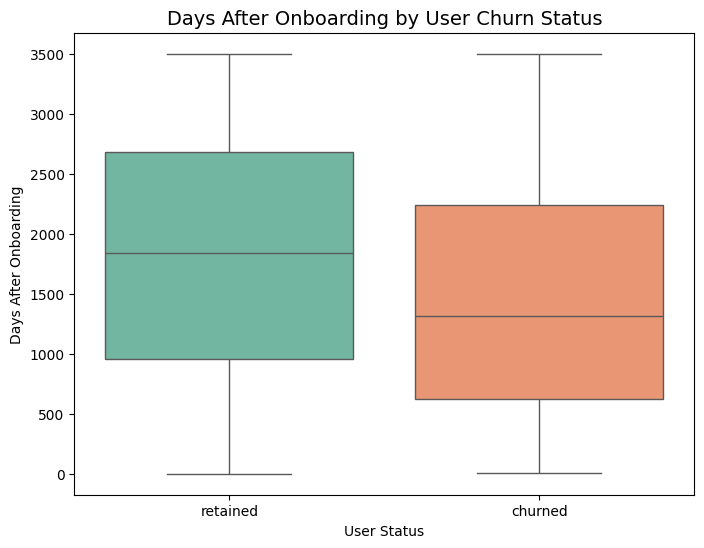

In [56]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='label',
    y='n_days_after_onboarding',
    palette='Set2'
)
plt.title('Days After Onboarding by User Churn Status', fontsize=14)
plt.xlabel('User Status')
plt.ylabel('Days After Onboarding')
plt.show()

# 5. Is churn associated with device type?


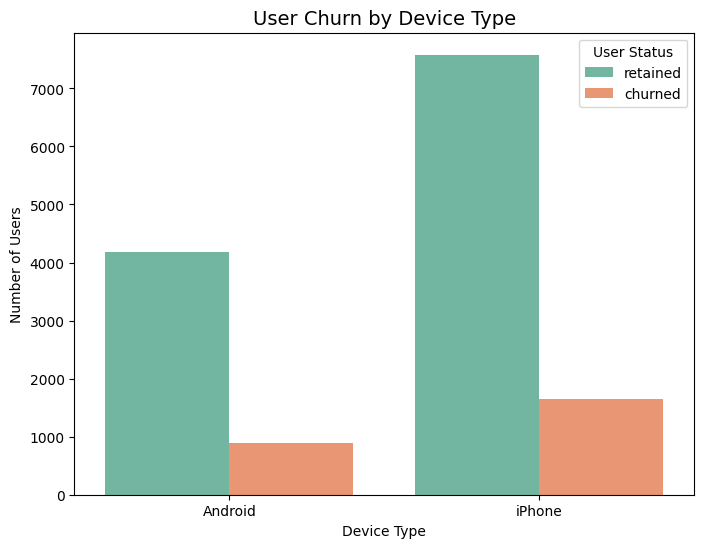

In [57]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x='device',
    hue='label',
    palette='Set2'
)

plt.title('User Churn by Device Type', fontsize=14)
plt.xlabel('Device Type')
plt.ylabel('Number of Users')
plt.legend(title='User Status')

plt.show()

# 6. What relationships exist among numerical variables?

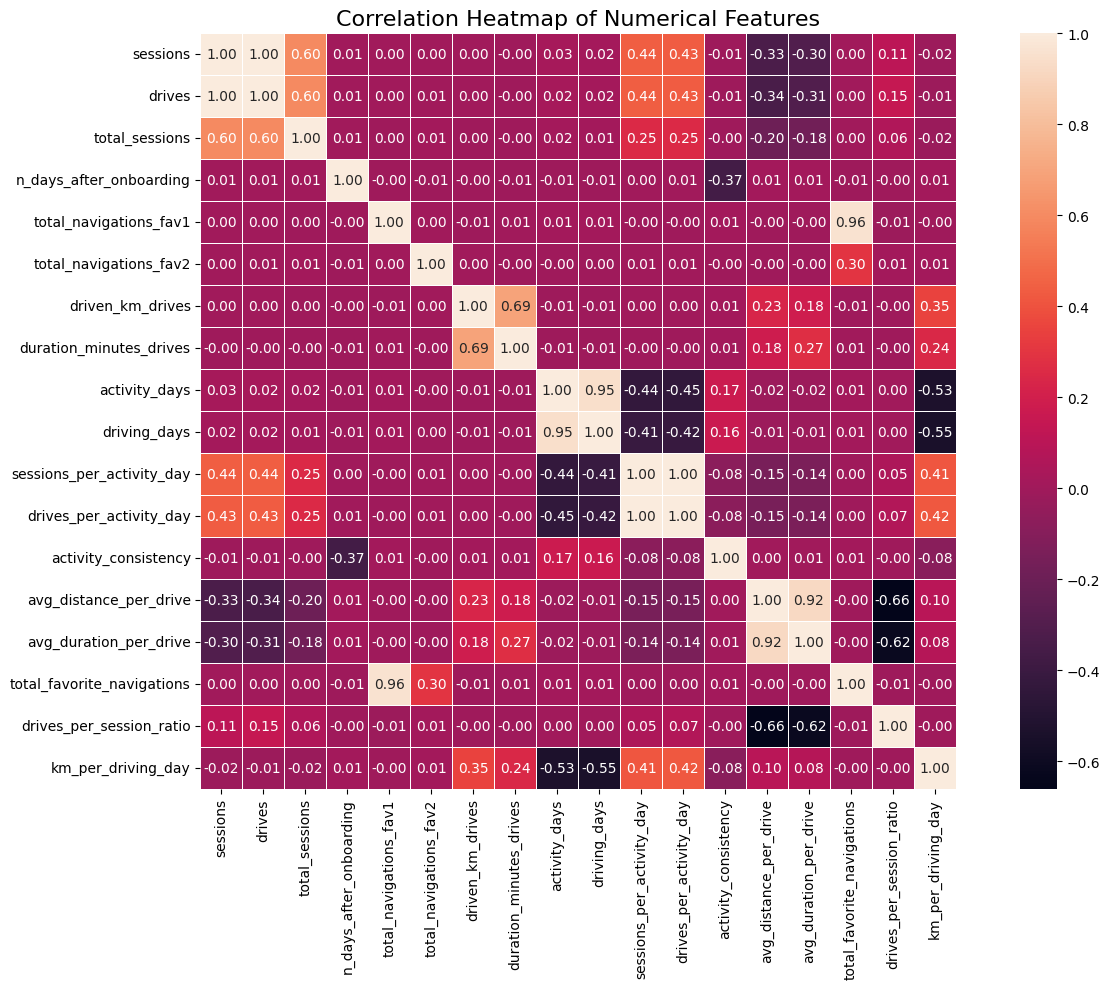

In [60]:
numerical_cols = df.select_dtypes(include='number')
corr_matrix = numerical_cols.corr()
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()

plt.show()

# 7. Do users with more sessions also complete more drives?


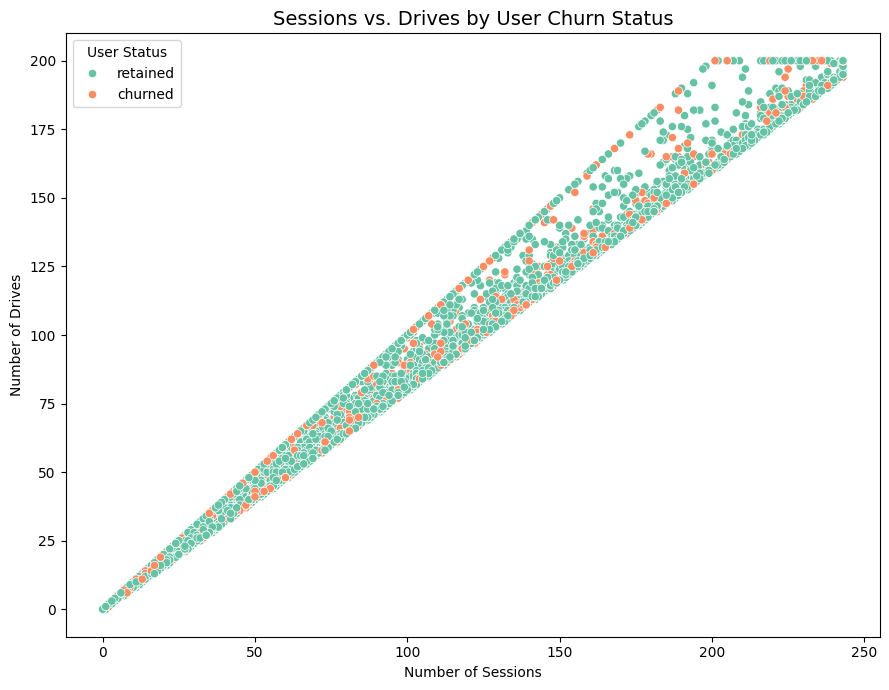

In [62]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df,
    x='sessions',
    y='drives',
    hue='label',
    palette='Set2'
)

plt.title('Sessions vs. Drives by User Churn Status', fontsize=14)
plt.xlabel('Number of Sessions')
plt.ylabel('Number of Drives')
plt.legend(title='User Status')

plt.tight_layout()
plt.show()

# 8. How does churn vary across activity levels?

In [65]:
df['activity_level'] = pd.qcut(df['activity_days'], q=4,
    labels=['Low', 'Moderate', 'High', 'Very High']
)

In [66]:
activity_churn = (df.groupby('activity_level', observed=True)['label'].apply(lambda x: (x == 'churned').mean() * 100)
      .reset_index(name='Churn Rate (%)')
)
activity_churn

,activity_level,Churn Rate (%)
0,Low,34.722222
1,Moderate,18.483146
2,High,9.941520
3,Very High,5.099150


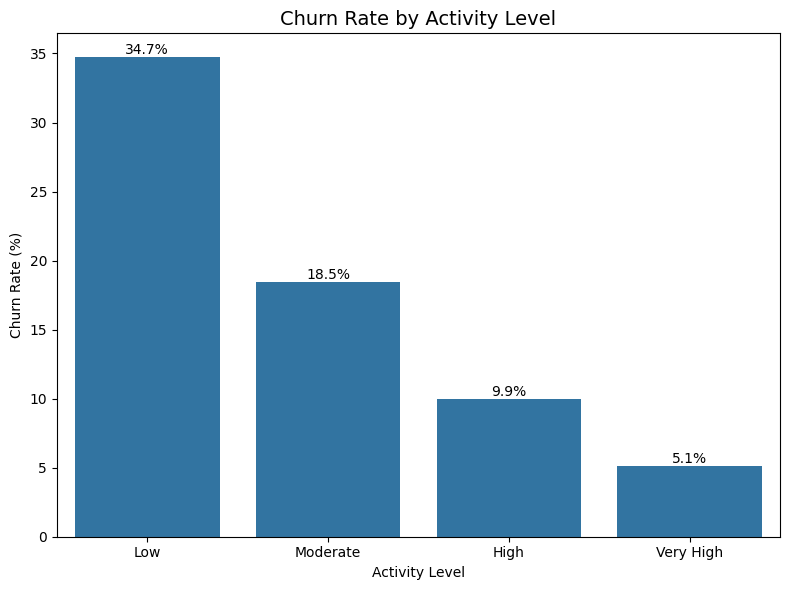

In [69]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=activity_churn,
    x='activity_level',
    y='Churn Rate (%)'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Churn Rate by Activity Level', fontsize=14)
plt.xlabel('Activity Level')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

# 9. How does churn change as the number of driving days increases?


In [70]:
df['driving_day_group'] = pd.cut(
    df['driving_days'],
    bins=[0, 5, 10, 15, 20, 25, 31],
    labels=[
        '1-5 days',
        '6-10 days',
        '11-15 days',
        '16-20 days',
        '21-25 days',
        '26-31 days'
    ]
)

In [71]:
driving_day_churn = (
    df.groupby('driving_day_group', observed=True)['label']
      .apply(lambda x: (x == 'churned').mean() * 100)
      .reset_index(name='Churn Rate (%)')
)

driving_day_churn

,driving_day_group,Churn Rate (%)
0,1-5 days,32.662362
1,6-10 days,22.003711
2,11-15 days,12.995427
3,16-20 days,7.956537
4,21-25 days,5.324544
5,26-31 days,3.153989


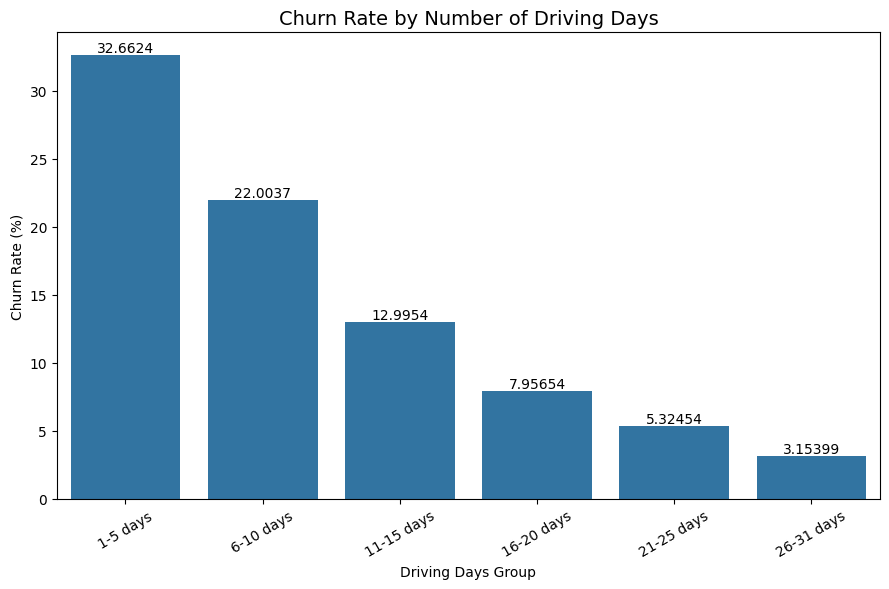

In [74]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=driving_day_churn,
    x='driving_day_group',
    y='Churn Rate (%)'
    )

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn Rate by Number of Driving Days', fontsize=14)
plt.xlabel('Driving Days Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 10. Are highly engaged users less likely to churn?


In [75]:
# Divide users into four groups based on sessions per active day
df['engagement_level'] = pd.qcut(
    df['sessions_per_activity_day'],
    q=4,
    labels=[
        'Low Engagement',
        'Moderate Engagement',
        'High Engagement',
        'Very High Engagement'
    ]
)

In [76]:
engagement_churn = (
    df.groupby('engagement_level', observed=True)['label']
      .apply(lambda x: (x == 'churned').mean() * 100)
      .reset_index(name='Churn Rate (%)')
)

engagement_churn

,engagement_level,Churn Rate (%)
0,Low Engagement,10.782948
1,Moderate Engagement,13.479360
2,High Engagement,15.974352
3,Very High Engagement,30.769231


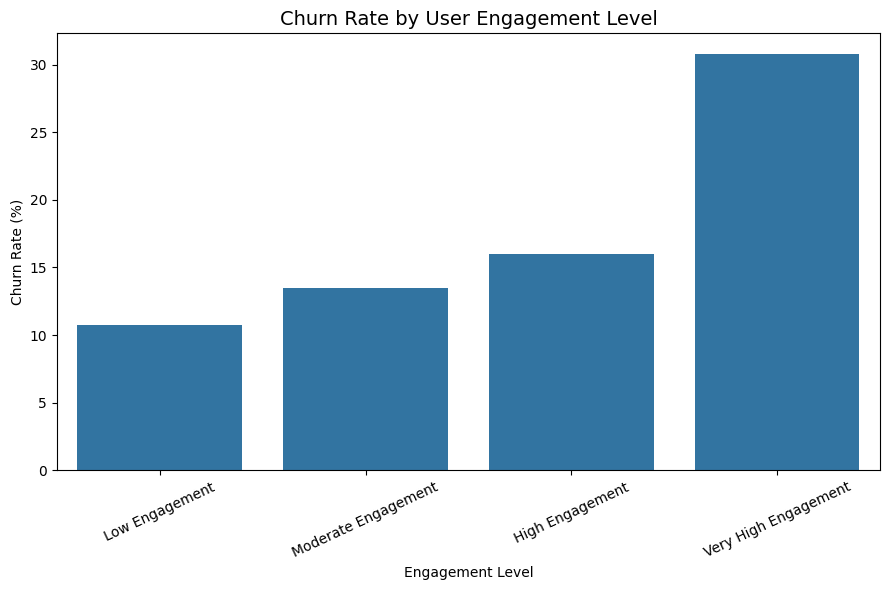

In [78]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=engagement_churn,
    x='engagement_level',
    y='Churn Rate (%)'
)

plt.title('Churn Rate by User Engagement Level', fontsize=14)
plt.xlabel('Engagement Level')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 11. Does converting app sessions into drives reduce churn?


In [79]:
# Divide users into four groups based on drives per session ratio

df['drive_conversion_level'] = pd.qcut(
    df['drives_per_session_ratio'],
    q=4,
    labels=[
        'Low Conversion',
        'Moderate Conversion',
        'High Conversion',
        'Very High Conversion'
    ]
)

In [81]:
drive_conversion_churn = (
    df.groupby('drive_conversion_level', observed=True)['label']
      .apply(lambda x: (x == 'churned').mean() * 100)
      .reset_index(name='Churn Rate (%)')
)
drive_conversion_churn

,drive_conversion_level,Churn Rate (%)
0,Low Conversion,15.763274
1,Moderate Conversion,17.492958
2,High Conversion,19.770050
3,Very High Conversion,17.942248


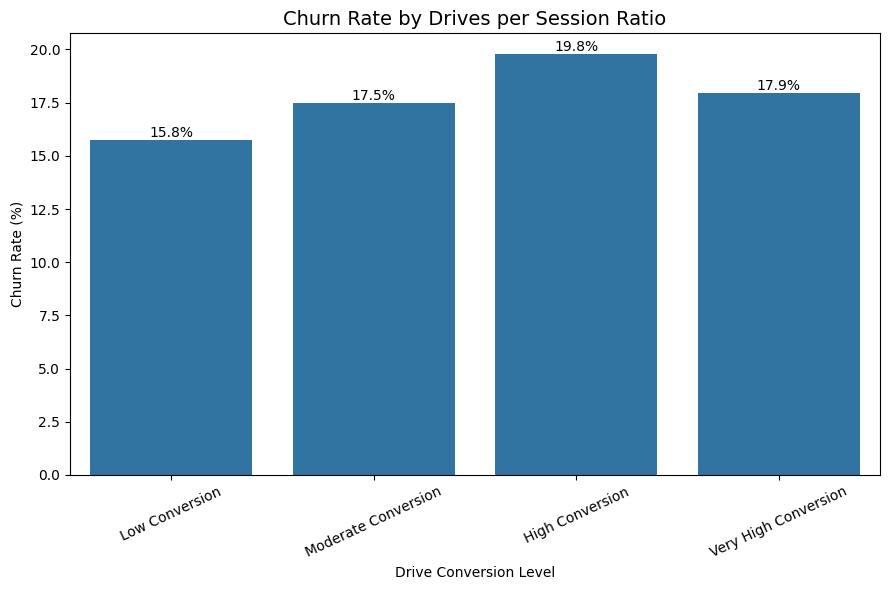

In [82]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=drive_conversion_churn,
    x='drive_conversion_level',
    y='Churn Rate (%)'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Churn Rate by Drives per Session Ratio', fontsize=14)
plt.xlabel('Drive Conversion Level')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 12. Do long-distance drivers behave differently from short-distance drivers?


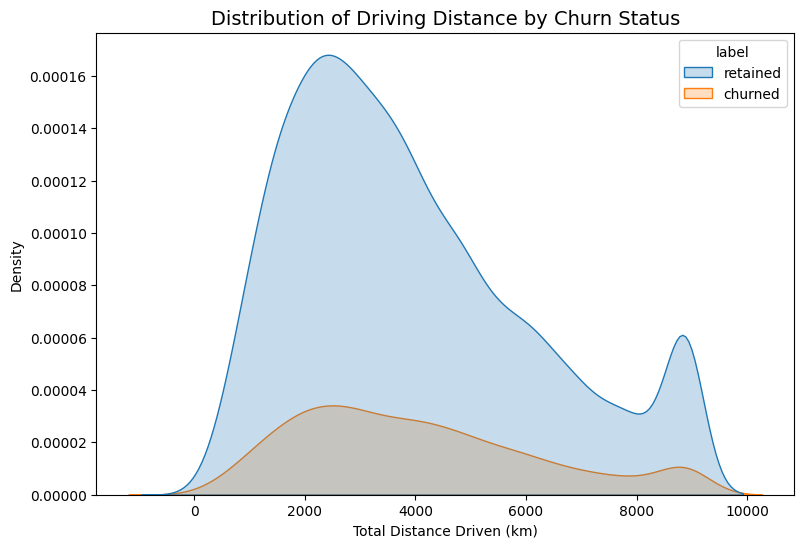

In [85]:
plt.figure(figsize=(9, 6))

sns.kdeplot(
    data=df,
    x='driven_km_drives',
    hue='label',
    fill=True
)

plt.title('Distribution of Driving Distance by Churn Status', fontsize=14)
plt.xlabel('Total Distance Driven (km)')
plt.ylabel('Density')

plt.show()

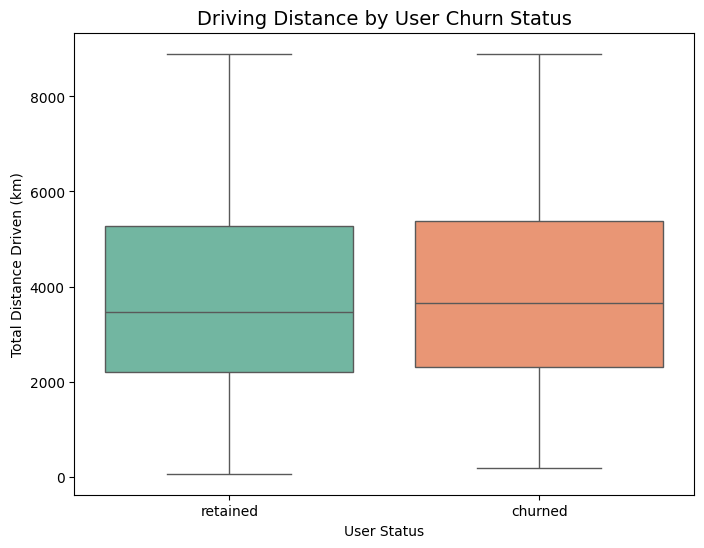

In [86]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='label',
    y='driven_km_drives',
    palette='Set2'
)

plt.title('Driving Distance by User Churn Status', fontsize=14)
plt.xlabel('User Status')
plt.ylabel('Total Distance Driven (km)')

plt.show()

In [87]:
df['distance_group'] = pd.qcut(
    df['driven_km_drives'],
    q=4,
    labels=[
        'Low Distance',
        'Moderate Distance',
        'High Distance',
        'Very High Distance'
    ]
)

In [88]:
distance_churn = (
    df.groupby('distance_group', observed=True)['label']
      .apply(lambda x: (x == 'churned').mean() * 100)
      .reset_index(name='Churn Rate (%)')
)

distance_churn

,distance_group,Churn Rate (%)
0,Low Distance,16.419580
1,Moderate Distance,16.867133
2,High Distance,19.194180
3,Very High Distance,18.461538


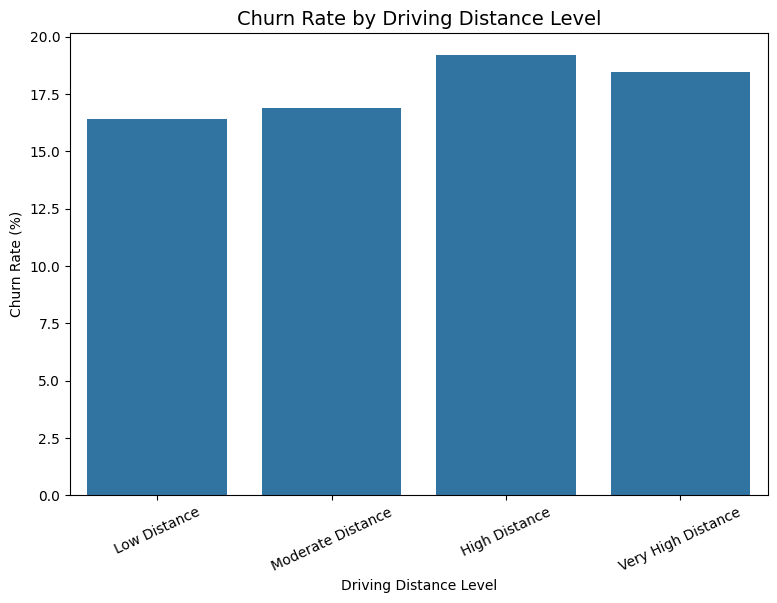

In [90]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=distance_churn,
    x='distance_group',
    y='Churn Rate (%)',
)
plt.title('Churn Rate by Driving Distance Level', fontsize=14)
plt.xlabel('Driving Distance Level')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=25)
plt.show()

# 13. What proportion of sessions occurred in the last month?


In [91]:
# Calculate the proportion of recent sessions compared to total sessions
df['recent_session_ratio'] = (df['sessions'] / (df['total_sessions'] + 1))

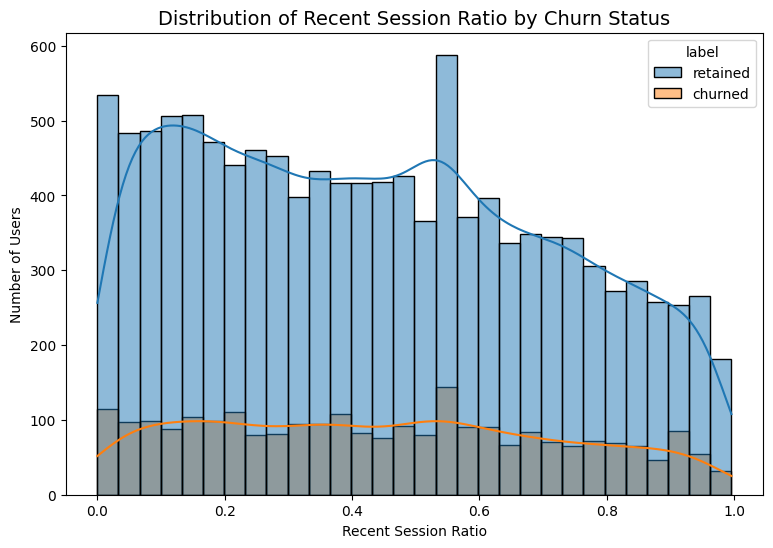

In [92]:
plt.figure(figsize=(9,6))

sns.histplot(
    data=df,
    x='recent_session_ratio',
    hue='label',
    bins=30,
    kde=True,
    alpha=0.5
)
plt.title(
    'Distribution of Recent Session Ratio by Churn Status',
    fontsize=14
)
plt.xlabel('Recent Session Ratio')
plt.ylabel('Number of Users')
plt.show()

In [94]:
# Calculate Churn Rate by Recent Engagement Level
df['recent_engagement_level'] = pd.qcut(
    df['recent_session_ratio'],
    q=4,
    labels=[
        'Low Recent Activity',
        'Moderate Recent Activity',
        'High Recent Activity',
        'Very High Recent Activity'
    ]
)

In [95]:
recent_churn = (
    df.groupby('recent_engagement_level', observed=True)['label']
      .apply(lambda x: (x == 'churned').mean()*100)
      .reset_index(name='Churn Rate (%)')
)

recent_churn

,recent_engagement_level,Churn Rate (%)
0,Low Recent Activity,16.727273
1,Moderate Recent Activity,17.818182
2,High Recent Activity,18.102966
3,Very High Recent Activity,18.293706


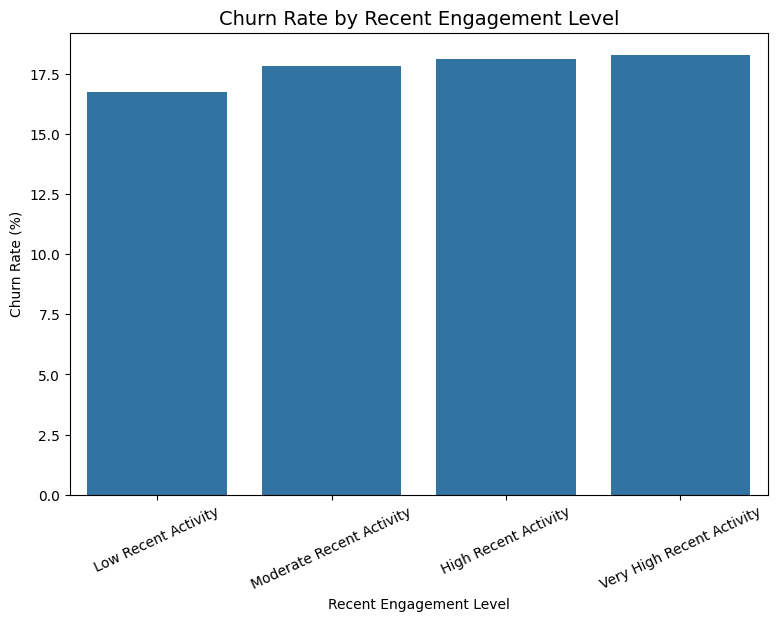

In [97]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=recent_churn,
    x='recent_engagement_level',
    y='Churn Rate (%)',
)
plt.title(
    'Churn Rate by Recent Engagement Level',
    fontsize=14
)
plt.xlabel('Recent Engagement Level')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=25)
plt.show()

## Key Insights & Conclusion

**Overall churn:** ~17.7% of labeled users churned during the month; the remaining
700 rows with no label were excluded from all churn comparisons above.

**What separates churned from retained users:**
- **Frequency, not volume, is the strongest signal.** Churned users are consistently
  in the lower activity/driving-day and engagement-level buckets — how *often* someone
  opens the app and drives predicts churn better than how much they drive per session.
- **`drives` and `sessions` are almost redundant** (very high correlation) — a churn
  model likely only needs one of the two, or an engineered ratio between them.
- **Device type (Android vs. iPhone) shows little to no difference in churn rate** —
  not a useful segmentation variable for retention efforts.
- **Newer users (lower `n_days_after_onboarding`) do not show a dramatically higher
  churn rate** in this dataset; tenure alone isn't a strong differentiator.
- Distance driven and drive-conversion ratio show more gradual, moderate relationships
  with churn — useful as secondary features rather than headline drivers.


**Next steps:** train/evaluate a churn classifier (e.g., logistic regression and a
tree-based model) on the cleaned, feature-engineered dataframe produced above, using the class-imbalance-aware techniques
